In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
# Single function imports
from scipy.integrate import quad, dblquad

We are interested in computing the following integral:
\begin{align*}
    I(x) = \int\limits_{ B(0,1) } K(x-y) \,\mathrm{d}y,
\end{align*}
where $ K(r) = \frac{1}{2\pi} \log |r| $. Since $K$ is radially symmetric, the integral will also be a radially symmetric function, thus it only matters how distant $x$ is from the origin. As a result, we can assume that $x = (a,0)$ with $a\in [0,1]$ and the integrand can be written as
\begin{align*}
    K(x-y) = \frac{1}{4\pi} \log \left( (a-y_1)^2 + y_2^2 \right) = \frac{1}{4\pi} \log \left( a^2 -2ay_1 + y_1^2 + y_2^2 \right).
\end{align*}
Let us introduce polar coordinates centred at the origin, which are handy to parametrise the domain. Then we have that
\begin{align*}
    I(x) = \frac{1}{4\pi} \int\limits_0^1 \int\limits_{0}^{2\pi}  s \log \left( a^2 -2a s \cos \theta  + s^2 \right)  \,\mathrm{d}\theta \,\mathrm{d}s.
\end{align*}

To compute this integral, we need to use Feynman's trick [[1]](https://math.stackexchange.com/questions/948764/how-to-integrate-int-0-pi-frac1a-b-cosx-dx-with-calculus-tools?lq=1&noredirect=1), [[2]](https://math.stackexchange.com/questions/1556217/how-to-find-int-02-pi-log-alpha-beta-cosx-mathrmdx). First, define $J(u,v) = \int\limits_0^{2\pi} \log\big( u - v \cos \theta \big) \,\mathrm{d}\theta$. From Young's inequality, we also can assert that in our case $u > v > 0$. Now, notice that 
\begin{align*}
    \dfrac{\partial J}{\partial u} = \int\limits_0^{2\pi} \dfrac{1}{u - v \cos \theta} \,\mathrm{d}\theta = \dfrac{2\pi}{\sqrt{u^2 - v^2}},
\end{align*}
then we have that
\begin{align*}
\tag{$\star$}
    J(u,v) = \int \dfrac{\partial J}{\partial u} \, \mathrm{d}u = (2\pi) \log\left( u + \sqrt{u^2 - v^2} \right) + C(v).
\end{align*}
Once again, we have that the initial expression yields [[3]](https://www.quora.com/How-do-I-prove-int_0-2-pi-frac-cos-x-a-cos-x-dx-2-pi-left-1-frac-a-sqrt-a-2-1-right-for-a-1)
\begin{align*}
    \dfrac{\partial J}{\partial v} = \int\limits_0^{2\pi} -\dfrac{\cos \theta}{u - v \cos \theta} \,\mathrm{d}\theta  
    = \frac{2\pi}{v} \left( 1 - \frac{u}{\sqrt{u^2-v^2}} \right)
    = \frac{2\pi}{v} \frac{-u + \sqrt{u^2-v^2}}{\sqrt{u^2-v^2}} 
    = \frac{2\pi}{v} \frac{-u + \sqrt{u^2-v^2}}{\sqrt{u^2-v^2}} \frac{u + \sqrt{u^2-v^2}}{u + \sqrt{u^2-v^2}}
    = (2\pi) \frac{-v}{\sqrt{u^2-v^2} \left( u + \sqrt{u^2-v^2} \right)}
\end{align*}
On the other hand $(\star)$ states that
\begin{align*}
    \dfrac{\partial J}{\partial v} &= (2\pi) \dfrac{\partial J}{\partial v}\log\left( u + \sqrt{u^2 - v^2} \right) + C'(v)
    = C'(v)  -\frac{2\pi v}{u^2 - v^2 + u \sqrt{u^2 - v^2}} = C'(v) -\frac{2\pi v}{\sqrt{u^2-v^2} \left( u + \sqrt{u^2 - v^2}\right)}
\end{align*}
for which we get that $C'(v) = 0$. Notice that $J(u,0) = C(0) + (2\pi) \log\left( 2 u \right) = 2\pi \log u$. As a result, we obtain that
\begin{align*}
    J(u,v) = (2\pi) \log\left( u + \sqrt{u^2 - v^2} \right) - (2\pi) \log\left( 2 \right) = (2\pi) \log\left( \frac{u + \sqrt{u^2 - v^2}}{2} \right).
\end{align*}

In [3]:
def integral_numeric(u,v):
    """
    Numerically approximates J(u,v) = ∫ₒ^{2π} log(u - v cos x) dx
    """
    return quad(lambda x: np.log(u - v * np.cos(x)), 0, 2*np.pi, epsabs=1e-10, epsrel=1e-10)[0]

def integral_closed(u,v):
    """
    Closed-form value: 2π log((u + √(u² − v²))/2)
    """
    return 2.0 * np.pi * np.log( 0.5 * (u + np.sqrt(u** 2 - v** 2)) )

In [4]:
tests = [(0.8, 0.7), (0.5, 0.1), (0.3,0.3), (0.01,0.01)]
for u,v in tests:
    num = integral_numeric(u,v)
    clo = integral_closed(u,v)
    print(f"u={u}, v={v}  →  numeric={num:.10f},  closed={clo:.10f},  diff={abs(num - clo):.2e}")

u=0.8, v=0.7  →  numeric=-3.2764722942,  closed=-3.2764722942,  diff=4.44e-16
u=0.5, v=0.1  →  numeric=-4.4189680215,  closed=-4.4189680215,  diff=0.00e+00
u=0.3, v=0.3  →  numeric=-11.9199564150,  closed=-11.9199564150,  diff=9.52e-13
u=0.01, v=0.01  →  numeric=-33.2903098303,  closed=-33.2903098303,  diff=1.67e-12


Now, let's select $u \leftarrow a^2 + s^2$ and $v \leftarrow 2as$. Then we have that
\begin{align*}
    I(x) &= \frac{1}{4\pi} \int\limits_0^1 s \int\limits_{0}^{2\pi}  J(u,v)  \,\mathrm{d}\theta \,\mathrm{d}s
    \\
    &= \frac{1}{2} \int\limits_0^1 s \log\left( \frac{a^2 + s^2 + \sqrt{(a^2 + s^2)^2 - (2as)^2}}{2} \right) \,\mathrm{d}s
    = \frac{1}{2} \int\limits_0^1 s \log\left( \frac{a^2 + s^2 + |a^2 - s^2|}{2} \right) \,\mathrm{d}s
    = \frac{1}{2} \int\limits_0^1 s \log\left( \max\{a^2, s^2\} \right) \,\mathrm{d}s
\end{align*}

The value of the integral will depend on three cases: (a) $a=0$, (b) $a=1$, and (c) $a \in (0,1)$. For the first two, we have that
\begin{align*}
    I(x) \big|_{a=0} &=
    \frac{1}{2}    \int\limits_0^1    s \log s^2 \, \mathrm{d}s = \frac{1}{4} s^2 \big( 2 \log s - 1 \big) \Bigg|_{0}^{1} = -\frac{1}{4},
    \\
    I(x) \big|_{a=1} &=
    \frac{1}{2}    \int\limits_0^1    s \log 1 \, \mathrm{d}s = 0.
\end{align*}
For the last case, we need to split the integral into two parts:
\begin{align*}
    I(x) \big|_{a\in(0,1)} &=
    \frac{1}{2}    \int\limits_0^a    s \log a^2 \, \mathrm{d}s + \frac{1}{2}    \int\limits_a^1    s \log s^2 \, \mathrm{d}s
    =
    \frac{1}{4} a^2 \log a^2    +   \frac{1}{4} ( a^2 - 2a^2 \log a -1 )
    =
    \frac{1}{4} ( a^2 -1 )
\end{align*}
Notice that the two limiting cases are included in this latter expression.

In [5]:
# Test J at arguments
def integral_numeric(a,s):
    """
    Numerically approximates J(a^2+s^2, 2as) = ∫ₒ^{2π} log(a^2+s^2 - 2as cos x) dx
    """
    u = a**2 + s**2
    v = 2*a*s
    return quad(lambda x: np.log(u - v * np.cos(x)), 0, 2*np.pi, epsabs=1e-10, epsrel=1e-15)[0]

def integral_closed(a,s):
    """
    Closed-form value: 2π log((u + √(u² − v²))/2)
    """
    return 2.0 * np.pi * np.log(  max(a**2,s**2) )

In [6]:
tests  = [(0.8, 0.7), (0.5, 0.1), (0.3,0.3), (1,0)]
tests += [a[::-1] for a in tests]
for u,v in tests:
    num = integral_numeric(u,v)
    clo = integral_closed(u,v)
    print(f"a={u}, s={v}  →  numeric={num:.10f},  closed={clo:.10f},  diff={abs(num - clo):.2e}")

a=0.8, s=0.7  →  numeric=-2.8041045660,  closed=-2.8041045660,  diff=7.11e-15
a=0.5, s=0.1  →  numeric=-8.7103443612,  closed=-8.7103443612,  diff=1.78e-15
a=0.3, s=0.3  →  numeric=-15.1295684688,  closed=-15.1295684688,  diff=1.44e-12
a=1, s=0  →  numeric=0.0000000000,  closed=0.0000000000,  diff=0.00e+00
a=0.7, s=0.8  →  numeric=-2.8041045660,  closed=-2.8041045660,  diff=7.11e-15
a=0.1, s=0.5  →  numeric=-8.7103443612,  closed=-8.7103443612,  diff=1.78e-15
a=0.3, s=0.3  →  numeric=-15.1295684688,  closed=-15.1295684688,  diff=1.44e-12
a=0, s=1  →  numeric=0.0000000000,  closed=0.0000000000,  diff=0.00e+00


---

In [7]:
J = lambda s, a: 0.5 * s * np.log(  np.maximum(a**2,s**2) )
quad(J, 0, 1, args=(0,), epsabs=1e-10, epsrel=1e-15), quad(J, 0, 1, args=(1,), epsabs=1e-10, epsrel=1e-15)

((-0.2499999999999998, 2.7755575615628894e-16), (0.0, 0.0))

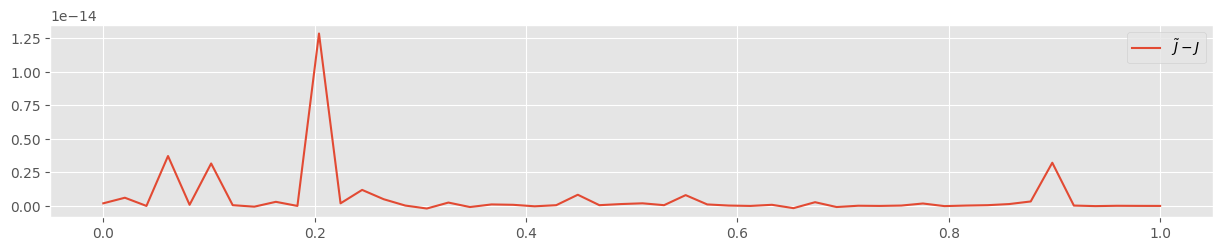

In [8]:
A = np.linspace(0,1)
plt.figure(figsize=(15,2.5))
plt.plot(A, [quad(J, 0, 1, args=(a,), epsabs=1e-15, epsrel=1e-13)[0] for a in A] - 0.25 *(A**2 - 1), label = r'$\tilde{J}-J$')
plt.legend()
plt.show()

In [9]:
def integral_numeric(a, ε=1e-10):
    """
    Numerically approximates I(a) = π/4 ∫_0^1 ∫_0^2π s log(a^2 + s^2 -2as cos(θ) ) dθ ds
    """
    f = lambda θ, s: s * np.log( a**2 + s**2 - 2*a*s*np.cos(θ) ) * 0.25 / np.pi
    return dblquad(f, 0, 1, 0, 2*np.pi, epsabs = ε, epsrel = ε)[0]

In [10]:
integral_numeric(0.0, ε=1e-14), integral_numeric(1.0, ε=1e-14)

(-0.24999999999999992, -3.7841156252142735e-17)

In [11]:
B = [integral_numeric(a, ε=1e-14) for a in A]

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be use

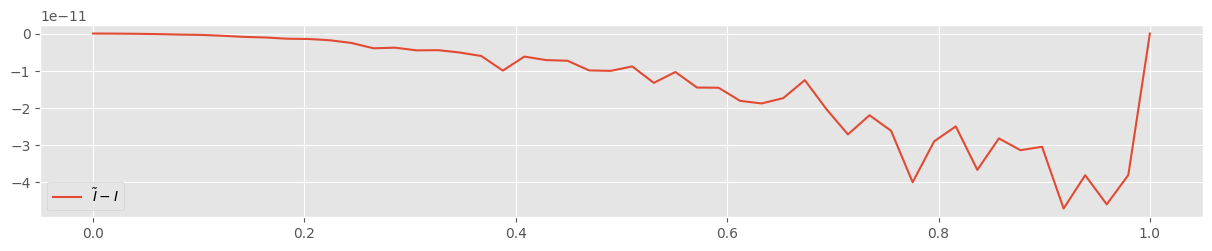

In [12]:
plt.figure(figsize=(15,2.5))
plt.plot(A, B-0.25 *(A**2 - 1), label = r'$\tilde{I}-I$' )
plt.legend()
plt.show()

As a result, we can compute the convolution $I(x)$ for any $x \in \overline{B}(0,1)$ using the formula
\begin{align*}
    I(x) = \frac{1}{4} (a^2 - 1) \big|_{a = \|x\|}.
\end{align*}

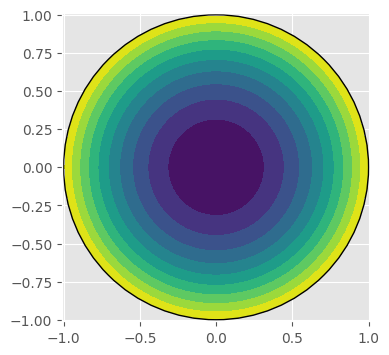

In [23]:
# Plot convolution
fig, ax = plt.subplots(1, figsize=(4,4))

# Make data.
X = np.arange(-1, 1, 0.01)
Y = np.arange(-1, 1, 0.01)
X, Y = np.meshgrid(X, Y)
R = 0.25 * (X**2 + Y**2 - 1)

# Mask values outside the unit disk
mask = X**2 + Y**2 > 1
R_masked = np.ma.masked_where(mask, R)

# Plot contours only inside the unit ball
surf = ax.contourf(X, Y, R_masked, levels=10)

# Draw the unit circle boundary for clarity
circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=1)
ax.add_artist(circle)

ax.set_aspect('equal')
plt.ylim(-1.01,1.01)
plt.xlim(-1.01,1.01)
plt.show()

Notice that the solution makes sense from a distributional point of view. We have that $ \Delta I(x) = \frac{1}{4} ( 2 + 2 ) = 1 $ and since $K$ is the Green function associated with the Poisson equation, the quantities agree.

---

# Additional computations

\begin{align*}
    \dfrac{\partial J}{\partial u} = \int\limits_0^{2\pi} \dfrac{1}{u - v \cos \theta} \,\mathrm{d}\theta = \dfrac{2\pi}{\sqrt{u^2 - v^2}},
\end{align*}

We follow the steps of [(2)](https://math.stackexchange.com/questions/1556217/how-to-find-int-02-pi-log-alpha-beta-cosx-mathrmdx) by means of complex integration. Here we write $\cos \theta = \frac{e^{i y} + e^{-i y}}{2}$, and thus
\begin{align*}
    \frac{1}{u - v \cos\theta} = \frac{1}{ u - v\frac{e^{i y} + e^{-i y}}{2}} = \frac{2 e^{iy}}{ 2u e^{iy} - ve^{2i y} - v }.
\end{align*}
Defining $z = e^{iy}$, for which $\mathrm{d}y = -\frac{i}{z}\mathrm{d}z$ and
\begin{align*}
    \int\limits_0^{2\pi} \dfrac{1}{u - v \cos \theta} \,\mathrm{d}\theta = 2
    \Re i \oint\limits_{|z|=1} \frac{\mathrm{d}z}{ vz^2 - 2u z + v }
\end{align*}

Since $ vz^2 - 2uz + v = v\left( z^2 - 2\frac{u}{v}z + 1 \right) = v \left( z - \frac{u + \sqrt{u^2 - v^2} }{v} \right)\left( z - \frac{u - \sqrt{u^2 - v^2} }{v} \right) = v(z - z_+)(z - z_-)$, we can use the residue theorem. There is only one residue inside the unit disc since $z_+ z_- = 1$ and it is given by $z_-$. Thus, the residue theorem allows us to obtain
\begin{align*}
    \oint\limits_{|z|=1} f(z) \,\mathrm{d}z = \oint\limits_{|z|=1} \frac{\mathrm{d}z}{ vz^2 - 2u z + v }
    = 2 \pi i \operatorname{Res} (f,z_-).
\end{align*}
Observe that
\begin{align*}
    \lim_{z \to z_-} \frac{(z-z_-)}{v(z - z_+)(z - z_-) } = \frac{1}{v(z_- - z_+)} %\frac{1}{ v(z_- - z_+)(z-z_-) } + \frac{1}{v(z_+ - z_-)(z-z_+)}
    =
    -\frac{1}{ 2 \sqrt{u^2 - v^2} }.
\end{align*}
As a result, we have that
\begin{align*}
    \int\limits_0^{2\pi} \dfrac{1}{u - v \cos \theta} \,\mathrm{d}\theta = 
    -2 \Re i \frac{2\pi i}{ 2 \sqrt{u^2 - v^2} }
    = \frac{2\pi}{ \sqrt{u^2 - v^2} }.
\end{align*}

---

\begin{align*}
    \dfrac{\partial J}{\partial v} = -\int\limits_0^{2\pi} \dfrac{\cos \theta}{u - v \cos \theta} \,\mathrm{d}\theta  
    = \frac{2\pi}{v} \left( 1 - \frac{u}{\sqrt{u^2-v^2}} \right).
\end{align*}

The integral can be computed in a similar fashion as before. First, observe that
\begin{align*}
    \frac{\cos \theta}{ u - v \cos \theta} = \frac{1}{2} \frac{ z + z^{-1} }{ u - v \frac{z+z^{-1}}{2} } = \frac{1}{z} \frac{ z^2 + 1 }{2 u - v(z+z^{-1})}
    = -\frac{z}{z} \frac{ z^2 + 1 }{vz^2 - 2uz + v} = -\frac{z}{z} \frac{ z^2 + 1 }{v(z-z_+)(z-z_-)}
\end{align*}
and thus
\begin{align*}
    \int\limits_0^{2\pi} \dfrac{\cos \theta}{u - v \cos \theta} \,\mathrm{d}\theta  = -\Re i \oint\limits_{|z|=1} f(z) \,\mathrm{d}z = \oint\limits_{|z|=1} -\frac{1}{z} \frac{ z^2 + 1 }{v(z-z_+)(z-z_-)} \,\mathrm{d}z 
\end{align*}

Now, there are two poles inside the contour, namely $z\in \{0, z_- \}$. Thus, we have that
\begin{align*}
    \operatorname{Res} (f,0) &= z f(z) \big|_{z=0} = -\frac{1}{v}
    \\
    \operatorname{Res} (f,z_-) &= (z-z_-) f(z) \big|_{z=z_-} =  \frac{u}{v\sqrt{u^2-v^2}}
\end{align*}

As a result, we have that
\begin{align*}
     \oint\limits_{|z|=1} f(z) \,\mathrm{d}z = 2 \pi i \big(\operatorname{Res} (f,0) + \operatorname{Res} (f,z_-) \big)
     =
     \frac{2\pi i}{v} \left( \frac{u}{v\sqrt{u^2-v^2}} - 1 \right)
\end{align*}
and thus
\begin{align*}
     -\int\limits_0^{2\pi} \dfrac{\cos \theta}{u - v \cos \theta} \,\mathrm{d}\theta 
     = 
     \frac{2\pi}{v} \left( 1- \frac{u}{v\sqrt{u^2-v^2}} \right)
\end{align*}

---

# Alternative derivation

There is another way to find the convolution without explicit integration. This can be seen from potential theory as we know that 
\begin{align*}
    \Delta I(x) &= 1 &&\text{in } B(0,1), 
    \\
    I(x) &= 0 &&\text{on } \delta B(0,1).
\end{align*}
We assume that $I$ is a radially symmetric function, for which we introduce the notation $I(x) = u(r)$. Thus, we can write the Laplacian of $I$ in the form
\begin{align*}
    \Delta I(x) = u''(r) + \frac{1}{r} u'(r) + \frac{1}{r^2} \underbrace{ \frac{\partial I}{\partial \theta} }_{0\text{: radial symmetry}} = 1.
\end{align*}
The ODE $r u'' + u' = r$ is an Euler-Cauchy equation. Notice that $\frac{\mathrm{d}}{\mathrm{d} r} ( r u' ) = r u'' + u'$, for which we have that
\begin{align*}
    \frac{\mathrm{d}}{\mathrm{d} r} ( r u' ) = r
    \Rightarrow
    r u' = \frac{1}{2}r^2 + c 
    \Rightarrow
    u(r) = \frac{1}{4} r^2 + c_1 \log r + c_2.
\end{align*}
To enforce continuity of $u$ at the origin, we must have that $c_1 = 0$, while the boundary condition states that $u(1) = 0 = \frac{1}{4} + c_2$. Thus, we have that
\begin{align*}
    u(r) = \frac{1}{4} (r^2 -1) = \frac{1}{4} \big( \|x\|^2 - 1 \big) = I(x).
\end{align*}

---